# 01 - Data Exploration

Characterises the three **romanised Hinglish** corpora this project uses, so the design
decisions in `02_baseline` and later notebooks are motivated by evidence.

| Dataset | Role | Expected balance |
|---|---|---|
| **Bohra 2018** | primary, standalone tweets | ~4,575 rows, 36% hate |
| **HASOC 2021 ICHCL** | training + cross-dataset test | ~48% hate |
| **HASOC 2022 ICHCL** | training + cross-dataset test | ~51% hate |

What each section feeds:
- class balance -> **macro-F1** + `class_weight='balanced'` (Objective 2)
- script mix -> the **romanised filter**
- base-rate + vocabulary divergence -> **cross-dataset generalisation** (Objective 3)
- romanisation variation in samples -> the **romanisation-variant attack** (Objective 4)

All charts are saved to `dissertation/writing/figures/` for the write-up.

> The Hugging Face `manueltonneau/india-hate-speech-superset` from the first draft is **not** used;
> the appendix documents why.

### 1. Setup

In [4]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception as e:
    print('Not on Colab / already mounted:', e)

Not on Colab / already mounted: No module named 'google.colab'


In [5]:
import sys
sys.path.insert(0, '/content/drive/MyDrive/dissertation/notebooks')

from hinglish_hate import (
    load_bohra, load_hasoc2021, load_hasoc2022_threads,
    filter_romanised, script_profile, clean_text,
)
import pandas as pd, numpy as np, json
from pathlib import Path
import matplotlib.pyplot as plt
print('imports OK')

imports OK


### 2. Locate data + figures folder

In [6]:
# DATA_ROOT = Path('/content/drive/MyDrive/dissertation/data')
# FIG_DIR   = Path('/content/drive/MyDrive/dissertation/writing/figures')

from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
DATA_ROOT = PROJECT_ROOT / 'data'
FIG_DIR = PROJECT_ROOT / 'writing' / 'figures'

FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Current directory:", Path.cwd())
print("DATA_ROOT:", DATA_ROOT)
print("DATA_ROOT exists:", DATA_ROOT.exists())

FIG_DIR.mkdir(parents=True, exist_ok=True)

def find_one(root, name):
    hits = list(Path(root).rglob(name))
    if not hits:
        raise FileNotFoundError(f'{name} not found under {root}')
    return hits[0]

def savefig(name):
    """Save the current figure to the writing/figures folder."""
    path = FIG_DIR / name
    plt.savefig(path, dpi=150, bbox_inches='tight')
    print('saved', path)

bohra_path = find_one(DATA_ROOT, 'hate_speech.tsv')
h21_labels = list(Path(DATA_ROOT).rglob('labels.json'))
h21_root   = h21_labels[0].parents[2] if h21_labels else None
print('Bohra   :', bohra_path)
print('HASOC21 :', h21_root)

Current directory: c:\Users\LENOVO\Desktop\dissertation\notebooks
DATA_ROOT: c:\Users\LENOVO\Desktop\dissertation\data
DATA_ROOT exists: True
Bohra   : c:\Users\LENOVO\Desktop\dissertation\data\hate_speech.tsv
HASOC21 : c:\Users\LENOVO\Desktop\dissertation\data\test-20220220T075607Z-001\test


### 3. Load the three corpora

HASOC 2022 uses the clean per-tweet thread loader (single utterances, not `final.csv`).

In [7]:
bohra = load_bohra(bohra_path)
h21   = load_hasoc2021(h21_root) if h21_root else None
h22   = load_hasoc2022_threads(DATA_ROOT)

sources = {'bohra2018': bohra, 'hasoc2021': h21, 'hasoc2022': h22}
sources = {k: v for k, v in sources.items() if v is not None}
for k, v in sources.items():
    print(f'{k:11s} loaded: {len(v):5d} rows')

[load_bohra] 4574 rows | fixed 0 label typo(s) | dropped 4 unparseable
bohra2018   loaded:  4574 rows
hasoc2021   loaded:  2092 rows
hasoc2022   loaded:  4901 rows


## 4. Class balance per source

Motivates the headline metric. Hate rate differs by source and each source is internally
imbalanced, so accuracy would flatter a majority guesser - hence **macro-F1** and
`class_weight='balanced'` in `02`.

,rows,hate,not,hate_%
bohra2018,4574,1660,2914,0.363
hasoc2021,2092,1037,1055,0.496
hasoc2022,4901,2518,2383,0.514


saved c:\Users\LENOVO\Desktop\dissertation\writing\figures\class_balance_by_source.png


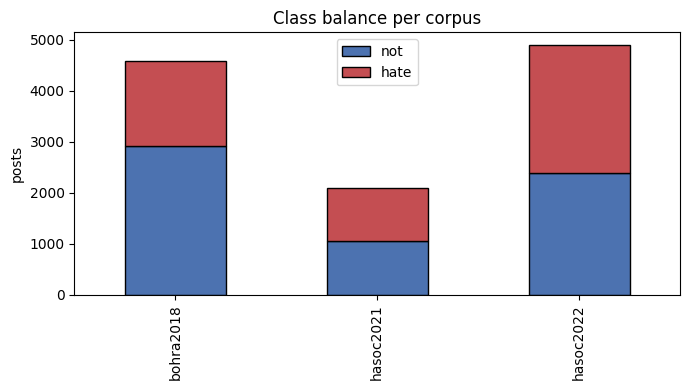

In [8]:
overview = pd.DataFrame({
    'rows':   {k: len(v) for k, v in sources.items()},
    'hate':   {k: int(v['label'].sum()) for k, v in sources.items()},
    'not':    {k: int((v['label']==0).sum()) for k, v in sources.items()},
    'hate_%': {k: round(v['label'].mean(), 3) for k, v in sources.items()},
})
display(overview)

ax = overview[['not','hate']].plot(kind='bar', stacked=True, figsize=(7,4),
                                   color=['#4c72b0','#c44e52'], edgecolor='black')
ax.set_ylabel('posts'); ax.set_title('Class balance per corpus'); ax.set_xlabel('')
plt.tight_layout(); savefig('class_balance_by_source.png'); plt.show()

## 5. Script mix -> the romanised filter

`script_profile` labels each post `mostly_latin` / `mixed_script` / `mostly_devanagari`. Bohra is
all romanised; the HASOC corpora carry a Devanagari tail the filter removes.

,bohra2018,hasoc2021,hasoc2022
script,,,
mixed_script,0,144,308
mostly_devanagari,0,261,595
mostly_latin,4574,1687,3998


,total,romanised_kept,kept_%
bohra2018,4574,4574,1.000
hasoc2021,2092,1831,0.875
hasoc2022,4901,4306,0.879


saved c:\Users\LENOVO\Desktop\dissertation\writing\figures\script_mix_by_source.png


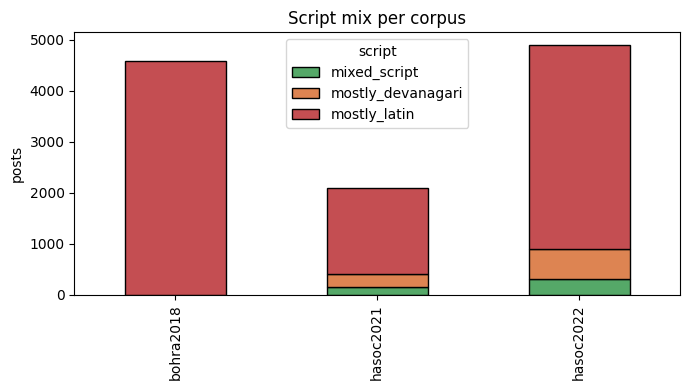

In [9]:
script_tab = pd.DataFrame({k: v['script'].value_counts() for k, v in sources.items()}).fillna(0).astype(int)
display(script_tab)

romanised = {k: len(filter_romanised(v, include_mixed=True)) for k, v in sources.items()}
cov = pd.DataFrame({'total': {k: len(v) for k,v in sources.items()}, 'romanised_kept': romanised})
cov['kept_%'] = (cov['romanised_kept']/cov['total']).round(3)
display(cov)

ax = script_tab.T.plot(kind='bar', stacked=True, figsize=(7,4), edgecolor='black',
                       color=['#55a868','#dd8452','#c44e52'])
ax.set_ylabel('posts'); ax.set_title('Script mix per corpus'); ax.set_xlabel('')
plt.tight_layout(); savefig('script_mix_by_source.png'); plt.show()

## 6. Post length distributions

Length per corpus and class - a sanity check on the loaders and context for later token-budget
choices in the transformer models.

,count,mean,std,min,25%,50%,75%,max
source,,,,,,,,
bohra2018,4574.0,20.0,10.4,1.0,12.0,19.0,25.0,67.0
hasoc2021,2092.0,16.0,12.7,2.0,7.0,12.0,21.0,65.0
hasoc2022,4901.0,20.9,15.0,2.0,9.0,16.0,30.0,66.0


saved c:\Users\LENOVO\Desktop\dissertation\writing\figures\post_length_by_source.png


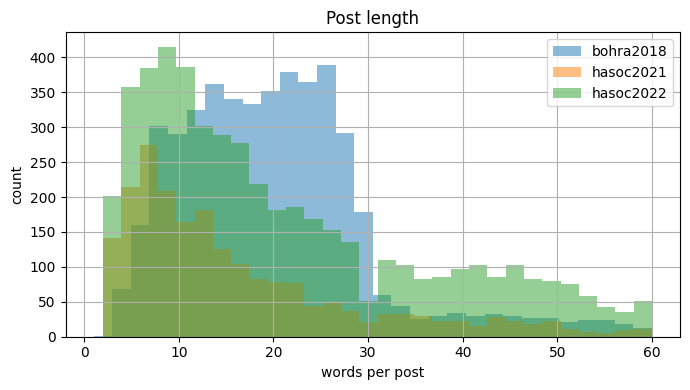

In [10]:
def add_len(df):
    d = df.copy()
    d['n_words'] = d['text'].str.split().str.len()
    d['n_chars'] = d['text'].str.len()
    return d

lens = pd.concat([add_len(v) for v in sources.values()], ignore_index=True)
display(lens.groupby('source')['n_words'].describe().round(1))

fig, ax = plt.subplots(figsize=(7,4))
for k, v in sources.items():
    add_len(v)['n_words'].clip(upper=60).hist(bins=30, alpha=0.5, label=k, ax=ax)
ax.set_xlabel('words per post'); ax.set_ylabel('count'); ax.legend(); ax.set_title('Post length')
plt.tight_layout(); savefig('post_length_by_source.png'); plt.show()

## 7. Read the data - 20 examples per class

Prints 20 posts per class per corpus (random, seeded). Read them: this is where the
**native-speaker observations** in the next section come from. The same samples are saved to
`writing/sample_posts_for_reading.csv` so you can annotate offline.

In [11]:
sample_rows = []
for k, v in sources.items():
    print(f'\n########## {k} ##########')
    for lab in (1, 0):
        sub = v[v['label']==lab]
        ex = sub.sample(min(20, len(sub)), random_state=42)
        print(f'\n----- {k} | label={lab} ({"hate" if lab else "not"}) | {len(ex)} shown -----')
        for i, t in enumerate(ex['text'].tolist(), 1):
            print(f'{i:2d}. {t[:200]}')
            sample_rows.append({'source':k, 'label':lab, 'text':t})

sample_df = pd.DataFrame(sample_rows)
sample_csv = FIG_DIR.parent / 'sample_posts_for_reading.csv'
sample_df.to_csv(sample_csv, index=False)
print('\nsaved', len(sample_df), 'sample posts ->', sample_csv)


########## bohra2018 ##########

----- bohra2018 | label=1 (hate) | 20 shown -----
 1. kitni gaand jalti hai bhai teri even srk fans hate u chutiye.
 2. jis chutiye ne,  bhansali ko ek thappad lagne par "HINDU TERROR " naam de diya tha....ye sab uski ammi ke shauhar... http://fb.me/1307Mb5nV
 3. aaj wo hi @ArvindKejriwal bol rha h jisne JNU ke RasLeela Sanchalak Kanhaiya ke "Army Rape krti h" byan ka support kita tha..
 4. Tere abba ne kitne nikah kiye? 4 se jyada? Behen se bhi kiye honge? Pak me aurte rape register nahi karti roj ki baat hai naa.
 5. Kuch indians itne ghatiya ho chuke hain k cricket ki baat kro tu terrorism k randi rone shru krdete hain
 6. Bijnor me rape !! Insaniyat sharamsar !! Lkin wajahid k nazdeek rape jurm ni !!
 7. Pehle mooh kholo rape Kiya hain khud ke logone, we know why u stay at home hijab ke android kya hain
 8. Ab khtaam Hogaya  tum mat larna mujh sy please I hate phaday bazi
 9. Yeah that's why I hate salman ,pichli baar bhi salman ne bahut bola tha G

## 8. Native-speaker observations

*Fill this in as you read Section 7. This qualitative read is your edge - a pipeline can't produce
it, and examiners value it. Prompts (delete what doesn't apply, add your own):*

- **Romanisation variants** seen (e.g. kya / kyaa / kia / kiya) - which words vary most?
- **Code-switching** patterns - where does Hindi flip to English within a post?
- **Sarcasm / context flips** - posts whose label only makes sense with the thread context.
- **Slurs / coded terms** a surface model would miss (caste, religious, regional).
- **Label calls you'd dispute** - anything you'd have annotated differently, and why.
- **Off-target rows** - English-only or Devanagari-only posts that slipped into a 'romanised Hinglish' set.
- **Cross-corpus feel** - does Bohra read differently from HASOC (topic, tone, length)?

*Your notes:*

- 
- 
- 

## 9. Cross-dataset divergence -> why generalisation is hard (Objective 3)

Base-rate gap and pairwise **Jaccard overlap of the top-500 tokens** on romanised text. Low overlap
plus shifting base rates are why a model trained on one corpus is expected to drop on another.

In [12]:
from collections import Counter

def top_tokens(df, n=500):
    c = Counter()
    for t in filter_romanised(df, include_mixed=True)['text']:
        c.update(clean_text(t).split())
    return set(w for w, _ in c.most_common(n))

tops = {k: top_tokens(v) for k, v in sources.items()}
keys = list(tops)
jac = pd.DataFrame(index=keys, columns=keys, dtype=float)
for a in keys:
    for b in keys:
        u = len(tops[a] | tops[b])
        jac.loc[a, b] = round(len(tops[a] & tops[b]) / u, 3) if u else 0.0
print('Base rate (hate %):', {k: round(v['label'].mean(),3) for k,v in sources.items()})
print('\nTop-500 token Jaccard overlap:')
display(jac)

Base rate (hate %): {'bohra2018': np.float64(0.363), 'hasoc2021': np.float64(0.496), 'hasoc2022': np.float64(0.514)}

Top-500 token Jaccard overlap:


,bohra2018,hasoc2021,hasoc2022
bohra2018,1.000,0.255,0.221
hasoc2021,0.255,1.000,0.527
hasoc2022,0.221,0.527,1.000


## 10. Hinglish hate lexicon

The statistical baseline is *TF-IDF **and lexicon*** + logistic regression; quick look at the lexicon.

In [13]:
lex = list(DATA_ROOT.rglob('hate_lexicon.txt'))
if lex:
    terms = [w.strip() for w in open(lex[0], encoding='utf-8') if w.strip()]
    print(f'{len(terms)} lexicon terms. Sample:', terms[:15])
else:
    print('hate_lexicon.txt not found under DATA_ROOT')

178 lexicon terms. Sample: ['nafrat', 'chaude', 'hate', 'hatred', 'murder', 'murderer', 'rape', 'neech', 'irritate', 'irritating', 'killing', 'dhamki', 'fake', 'nakli', 'chutiya']


## 11. Summary -> design decisions

- Three romanised corpora, all imbalanced with differing base rates -> macro-F1 + `class_weight='balanced'`.
- HASOC corpora carry a Devanagari tail -> romanised filter before every experiment.
- Low cross-corpus token overlap + base-rate shift -> a real generalisation gap to measure.
- Romanisation variation in the samples -> basis for the romanisation-variant attack.

Charts saved to `writing/figures/`: `class_balance_by_source.png`, `script_mix_by_source.png`,
`post_length_by_source.png`. Sample posts: `writing/sample_posts_for_reading.csv`.

## Appendix - why the Hugging Face superset was excluded

The first draft explored `manueltonneau/india-hate-speech-superset`. Script profiling showed it is
overwhelmingly **Devanagari**, not romanised Hinglish, so it is excluded. Reproduced here as an
audit trail (needs `datasets`).

In [14]:
# Optional audit - uncomment to reproduce the rejection finding.
# from datasets import load_dataset
# sup = pd.DataFrame(load_dataset('manueltonneau/india-hate-speech-superset')['train'])
# sup['script'] = sup['text'].map(script_profile)
# print(sup['script'].value_counts(normalize=True).round(3))  # mostly_devanagari dominates (~0.9)